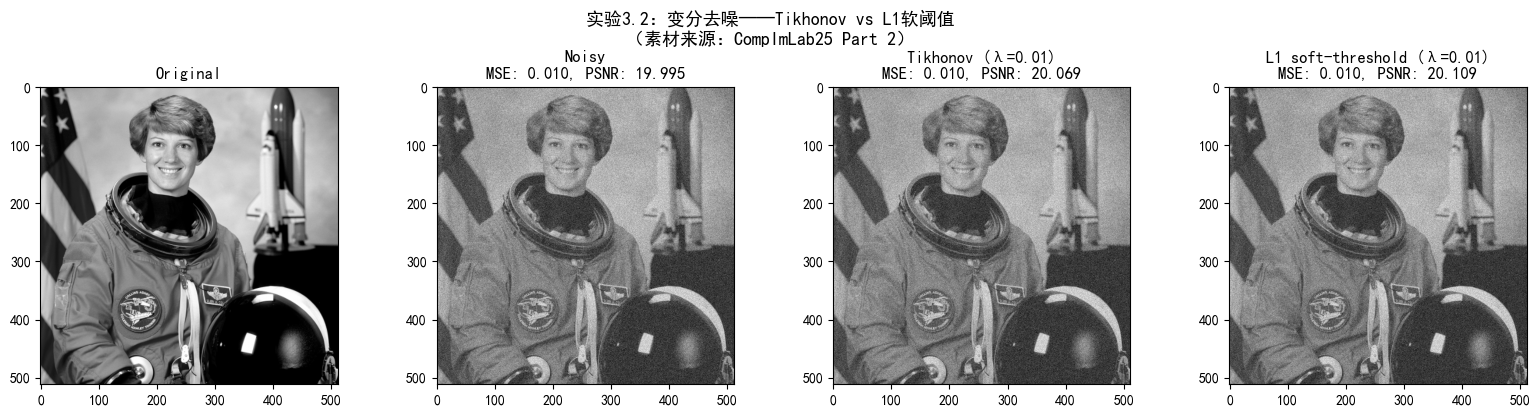

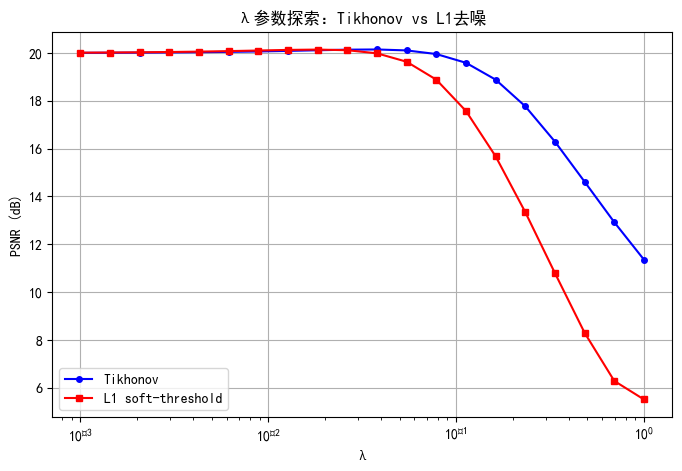

In [11]:
"""
实验3.2 变分去噪：Tikhonov vs L1软阈值
对应章节：3.3（Tikhonov闭式解 x=y/(1+λ)）、3.4（L1近端算子→软阈值）
素材来源：Mathematics and Machine Learning for image analysis/
          Computational Imaging Lab Activities/CompImLab25.ipynb Part 2
          winter_school/BolognaWinterSchool2023-main/Matlab/Smu.m (软阈值函数Python翻译)
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
 
# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
 
# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

from skimage.data import astronaut
from skimage.color import rgb2gray
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio

# ---- 图像加载（取自CompImLab25 Cell 1）----
x_gray = rgb2gray(astronaut())

# ---- 变分去噪（取自CompImLab25 Part 2 Cell 2）----
x = x_gray
n = x.shape[0]

noise_lev = 1e-1
y = x + noise_lev * np.random.randn(n, n)

# Tikhonov去噪: x_λ = y / (1+λ)  （3.3节闭式解，A=I的特殊情形）
lambda_Tikh = 1e-2
x_Tikh = y / (1 + lambda_Tikh)

# L1软阈值去噪: x_λ = prox_{λ||·||_1}(y) = S_λ(y)  （3.4节近端算子）
# 取自Smu.m的Python翻译
def soft_thresh(x, l):
    """软阈值算子 S_l(x) = sign(x) * max(|x|-l, 0)
    翻译自 Smu.m (Daubechies, Defrise and De Mol 2004)
    """
    return np.multiply(np.sign(x), np.maximum(np.abs(x) - l, np.zeros_like(x)))

lambda_Lasso = 1e-2
x_Lasso = soft_thresh(y, lambda_Lasso)

# MSE/PSNR评估
Orig_MSE = mean_squared_error(x, y)
Tikh_MSE = mean_squared_error(x, x_Tikh)
Lasso_MSE = mean_squared_error(x, x_Lasso)
Orig_PSNR = peak_signal_noise_ratio(x, y)
Tikh_PSNR = peak_signal_noise_ratio(x, x_Tikh)
Lasso_PSNR = peak_signal_noise_ratio(x, x_Lasso)

# 可视化（取自CompImLab25 Part 2 Cell 2 原始绘图逻辑）
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(x, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(y, cmap='gray')
axs[1].set_title(f'Noisy\nMSE: {Orig_MSE:.3f}, PSNR: {Orig_PSNR:.3f}')
axs[2].imshow(x_Tikh, cmap='gray')
axs[2].set_title(f'Tikhonov (λ={lambda_Tikh})\nMSE: {Tikh_MSE:.3f}, PSNR: {Tikh_PSNR:.3f}')
axs[3].imshow(x_Lasso, cmap='gray')
axs[3].set_title(f'L1 soft-threshold (λ={lambda_Lasso})\nMSE: {Lasso_MSE:.3f}, PSNR: {Lasso_PSNR:.3f}')
plt.suptitle('实验3.2：变分去噪——Tikhonov vs L1软阈值\n（素材来源：CompImLab25 Part 2）', fontsize=13)
plt.tight_layout()
plt.show()

# ---- λ参数探索（取自CompImLab25 Part 2 Cell 3末尾TASK提示）----
lambdas = np.logspace(-3, 0, 20)
psnrs_tikh = []
psnrs_lasso = []
for l in lambdas:
    x_t = y / (1 + l)
    x_l = soft_thresh(y, l)
    psnrs_tikh.append(peak_signal_noise_ratio(x, x_t))
    psnrs_lasso.append(peak_signal_noise_ratio(x, x_l))

plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, psnrs_tikh, 'b-o', markersize=4, label='Tikhonov')
plt.semilogx(lambdas, psnrs_lasso, 'r-s', markersize=4, label='L1 soft-threshold')
plt.xlabel('λ')
plt.ylabel('PSNR (dB)')
plt.title('λ参数探索：Tikhonov vs L1去噪')
plt.legend()
plt.grid(True)
plt.show()
